# PRAGMA-lite masked-transaction training

This notebook trains the current end-to-end model: **Event Encoder → Profile Encoder → History Encoder → masked-field MLM head**. It uses the account-disjoint train/validation parquet splits created in the exploration notebook.

## Before running in a Colab runtime

The VS Code Colab extension runs code on a remote Colab machine; it cannot see this Windows folder by itself. The recommended setup is to put the project on the Colab VM's fast, temporary `/content` disk, not to train from mounted Drive. The setup cell can clone a public Git repository, or you can upload one project zip directly from your laptop.

- `finBERTlitemodules/`
- `data/processed/czech_bank/`
- `financial_db_Teradata/`

The project material needed for this experiment is about 71 MiB, so a direct zip upload is perfectly reasonable. It does **not** consume Google Drive storage, but it must be repeated after the Colab VM resets. In Colab, select a GPU runtime before you run the notebook. The configuration cell is the one place to change batch size, epochs, or a resume checkpoint.

In [3]:
# Install the one dependency Colab may not already have. This installs
# into the current temporary VM, not into Google Drive.
%pip install -q pyarrow scikit-learn

import shutil
import sys
from pathlib import Path

IN_COLAB = 'google.colab' in sys.modules
PROJECT_ROOT = Path('/content/FinancialBertForTransactions') if IN_COLAB else Path.cwd()

# OPTION A — recommended after you push this repository to GitHub. Set the
# URL once, then the code is cloned onto the Colab VM at each new session.
REPOSITORY_URL = 'https://github.com/Extraterrestrial-T/FinancialBertForTransactions'  # e.g. 'https://github.com/YOUR_USERNAME/FinancialBertForTransactions.git'
if IN_COLAB and REPOSITORY_URL and not PROJECT_ROOT.exists():
    !git clone --depth=1 {REPOSITORY_URL} {PROJECT_ROOT}

# OPTION B — no Drive and no GitHub needed. First zip this project on your
# laptop, then change this to True and choose that zip in the upload dialog.
# The zip must unpack to /content/FinancialBertForTransactions/.
UPLOAD_PROJECT_ZIP = False
if IN_COLAB and UPLOAD_PROJECT_ZIP and not PROJECT_ROOT.exists():
    from google.colab import files
    uploaded = files.upload()
    if len(uploaded) != 1:
        raise ValueError('Choose exactly one project zip archive.')
    archive_path = Path(next(iter(uploaded)))
    shutil.unpack_archive(archive_path, '/content')

PROJECT_ROOT = PROJECT_ROOT.resolve()
assert (PROJECT_ROOT / 'finBERTlitemodules').exists(), (
    f'Cannot find the project at {PROJECT_ROOT}. Use Option A or Option B above.'
)
# This makes `from finBERTlitemodules import ...` work exactly as it does
# locally: Python looks for packages relative to the project root.
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f'Project root: {PROJECT_ROOT}')
print(f'Running in Colab: {IN_COLAB}')
if IN_COLAB:
    !nvidia-smi

AssertionError: Cannot find the project at /content/FinancialBertForTransactions. Use Option A or Option B above.

## Persistent checkpoints in Google Drive

The model, data, and training batches remain on the fast `/content` disk. This cell mounts Drive only for small persistent artifacts: `best.pt`, `last.pt`, tokenizer states, and `metrics.csv`.

In [3]:
# Keep training I/O on /content, but preserve restartable artifacts in Drive.
PERSIST_CHECKPOINTS_TO_DRIVE = True

if IN_COLAB and PERSIST_CHECKPOINTS_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    ARTIFACT_ROOT = Path('/content/drive/MyDrive/FinancialBertForTransactions')
else:
    ARTIFACT_ROOT = PROJECT_ROOT

ARTIFACT_ROOT.mkdir(parents=True, exist_ok=True)
print(f'Persistent artifacts: {ARTIFACT_ROOT}')

Mounted at /content/drive
Persistent artifacts: /content/drive/MyDrive/FinancialBertForTransactions


## Imports and configuration

The split is by `account_id`, not transaction row. Tokenizer boundaries are fitted **only** from the train split and then reused for validation. `MAX_EVENTS` is the history context window; events before that window are excluded from the current sample.

In [4]:
from dataclasses import asdict
from time import perf_counter

import pandas as pd
import torch
from torch import Tensor
from torch.nn import functional as F
from torch.utils.data import DataLoader

from finBERTlitemodules import (
    EventMLMDemoModel,
    FinBERTLiteCzechDataset,
    TransformerConfig,
    apply_value_mlm_mask,
    collate_account_records,
    fit_tokenizer_bundle,
    save_tokenizer_bundle,
)

SEED = 42
EPOCHS = 300
BATCH_SIZE = 128         # Start here on a Colab T4/L4; increase only after one epoch works.
MAX_EVENTS = 256
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-2
GRAD_CLIP_NORM = 1.0
NUM_WORKERS = 2 if torch.cuda.is_available() else 0

# Set to e.g. CHECKPOINT_DIR / 'last.pt' to continue an interrupted run.
RESUME_FROM = None

DATA_DIR = PROJECT_ROOT / 'data' / 'processed' / 'czech_bank'
SOURCE_DIR = PROJECT_ROOT / 'financial_db_Teradata'
CHECKPOINT_DIR = ARTIFACT_ROOT / 'checkpoints_swoll' / 'pragma_lite_mlm'
TOKENIZER_DIR = CHECKPOINT_DIR / 'tokenizers'
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_EVENTS = DATA_DIR / 'events_train.parquet'
TRAIN_PROFILES = DATA_DIR / 'profile_train.parquet'
VALID_EVENTS = DATA_DIR / 'events_valid.parquet'
VALID_PROFILES = DATA_DIR / 'profile_valid.parquet'
for required_path in (TRAIN_EVENTS, TRAIN_PROFILES, VALID_EVENTS, VALID_PROFILES, SOURCE_DIR):
    assert required_path.exists(), f'Missing required path: {required_path}'

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
AMP_ENABLED = DEVICE.type == 'cuda'
torch.manual_seed(SEED)
if DEVICE.type == 'cuda':
    torch.cuda.manual_seed_all(SEED)

print(f'Device: {DEVICE}; mixed precision: {AMP_ENABLED}')

Device: cuda; mixed precision: True


## Fit the train-only tokenizer bundle and build datasets

This happens once at the beginning of a fresh run. The resulting tokenizer states are saved with the checkpoint so validation and a future resumed run use identical numeric bucket boundaries.

In [5]:
# `fit_tokenizer_bundle` may take a moment because it reads the train split
# and the lifetime source tables. It never reads validation data to fit bins.
train_events_frame = pd.read_parquet(TRAIN_EVENTS)
train_profiles_frame = pd.read_parquet(TRAIN_PROFILES)
tokenizers = fit_tokenizer_bundle(train_events_frame, train_profiles_frame, SOURCE_DIR)
save_tokenizer_bundle(tokenizers, TOKENIZER_DIR)
vocabulary_size = len(tokenizers.event.token_to_id)
del train_events_frame, train_profiles_frame

train_dataset = FinBERTLiteCzechDataset(
    TRAIN_EVENTS, TRAIN_PROFILES, SOURCE_DIR, tokenizers,
    max_events=MAX_EVENTS, random_cutoff=True, seed=SEED,
)
valid_dataset = FinBERTLiteCzechDataset(
    VALID_EVENTS, VALID_PROFILES, SOURCE_DIR, tokenizers,
    max_events=MAX_EVENTS, random_cutoff=False, seed=SEED,
)

loader_kwargs = {
    'batch_size': BATCH_SIZE,
    'num_workers': NUM_WORKERS,
    'pin_memory': DEVICE.type == 'cuda',
    'collate_fn': collate_account_records,
}
train_loader = DataLoader(
    train_dataset, shuffle=True,
    generator=torch.Generator().manual_seed(SEED),
    **loader_kwargs,
)
valid_loader = DataLoader(valid_dataset, shuffle=False, **loader_kwargs)

print(f'Train accounts: {len(train_dataset):,}')
print(f'Valid accounts: {len(valid_dataset):,}')
print(f'Vocabulary size: {vocabulary_size}')
print(f'Train batches/epoch: {len(train_loader):,}')

Train accounts: 3,138
Valid accounts: 672
Vocabulary size: 113
Train batches/epoch: 25


## Create the model and the training helpers

The MLM labels are the original values at selected field positions; all other labels are `-100` and are ignored by cross-entropy. The event keys remain visible, so the prediction head knows which field's candidate distribution it is modelling.

In [6]:
MODEL_CONFIG = TransformerConfig(
    d_model=144,
    num_heads=8,
    num_layers=3,
    ffn_dim=288,
    dropout=0.1,
)
model = EventMLMDemoModel(vocabulary_size, MODEL_CONFIG).to(DEVICE)
optimizer = torch.optim.AdamW(
    model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
scaler = torch.amp.GradScaler(DEVICE.type, enabled=AMP_ENABLED)

def move_tensors(batch: dict[str, object]) -> dict[str, object]:
    return {
        name: value.to(DEVICE, non_blocking=True) if isinstance(value, Tensor) else value
        for name, value in batch.items()
    }

def forward_from_batch(masked_batch: dict[str, object]):
    return model(
        masked_batch['event_key_ids'],
        masked_batch['event_value_ids'],
        masked_batch['event_mask'],
        masked_batch['profile_key_ids'],
        masked_batch['profile_value_ids'],
        masked_batch['profile_mask'],
        masked_batch['profile_rope_time'],
        masked_batch['history_rope_time'],
        masked_batch['calendar_features'],
    )

def mlm_cross_entropy(logits: Tensor, labels: Tensor) -> Tensor:
    return F.cross_entropy(
        logits.reshape(-1, logits.shape[-1]),
        labels.reshape(-1),
        ignore_index=-100,
    )

def make_mask_generator(seed: int) -> torch.Generator:
    # `apply_value_mlm_mask` samples directly on the batch's device.
    return torch.Generator(device=DEVICE.type).manual_seed(seed)

print(f'Model parameters: {sum(parameter.numel() for parameter in model.parameters()):,}')

Model parameters: 1,589,585


## Optional: resume an interrupted run

Set `RESUME_FROM = CHECKPOINT_DIR / 'last.pt'` in the configuration cell, then run this cell before training. The same tokenizer state saved in `TOKENIZER_DIR` should accompany the checkpoint.

In [7]:
start_epoch = 1
best_validation_loss = float('inf')
if RESUME_FROM is not None:
    checkpoint = torch.load(RESUME_FROM, map_location=DEVICE)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
    start_epoch = int(checkpoint['epoch']) + 1
    best_validation_loss = float(checkpoint['best_validation_loss'])
    print(f'Resumed after epoch {start_epoch - 1}; best validation loss={best_validation_loss:.4f}')
else:
    print('Starting a fresh run.')

Starting a fresh run.


## Train and validate

Every training epoch uses deterministic but different random cutoff days through `train_dataset.set_epoch(epoch)`. Validation always uses each account's final cutoff day. The validation mask is reset to a fixed seed each epoch, so its loss is comparable over time.

In [8]:
history: list[dict[str, float]] = []
train_mask_generator = make_mask_generator(SEED + 100)

for epoch in range(start_epoch, EPOCHS + 1):
    epoch_start = perf_counter()
    train_dataset.set_epoch(epoch)
    model.train()
    train_loss_sum = 0.0
    train_target_count = 0

    for raw_batch in train_loader:
        batch = move_tensors(raw_batch)
        masked_batch = apply_value_mlm_mask(batch, generator=train_mask_generator)
        optimizer.zero_grad(set_to_none=True)

        with torch.autocast(device_type=DEVICE.type, dtype=torch.float16, enabled=AMP_ENABLED):
            output = forward_from_batch(masked_batch)
            loss = mlm_cross_entropy(output.logits, masked_batch['mlm_labels'])

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
        scaler.step(optimizer)
        scaler.update()

        target_count = int(masked_batch['mlm_mask'].sum().item())
        train_loss_sum += loss.item() * target_count
        train_target_count += target_count

    model.eval()
    valid_loss_sum = 0.0
    valid_target_count = 0
    valid_mask_generator = make_mask_generator(SEED + 200)
    with torch.no_grad():
        for raw_batch in valid_loader:
            batch = move_tensors(raw_batch)
            masked_batch = apply_value_mlm_mask(batch, generator=valid_mask_generator)
            with torch.autocast(device_type=DEVICE.type, dtype=torch.float16, enabled=AMP_ENABLED):
                output = forward_from_batch(masked_batch)
                loss = mlm_cross_entropy(output.logits, masked_batch['mlm_labels'])
            target_count = int(masked_batch['mlm_mask'].sum().item())
            valid_loss_sum += loss.item() * target_count
            valid_target_count += target_count

    if train_target_count == 0 or valid_target_count == 0:
        raise RuntimeError('No MLM targets were selected; check masking probabilities.')
    train_loss = train_loss_sum / train_target_count
    valid_loss = valid_loss_sum / valid_target_count
    current_lr = optimizer.param_groups[0]['lr']
    scheduler.step()
    elapsed_seconds = perf_counter() - epoch_start

    epoch_record = {
        'epoch': float(epoch),
        'train_loss': train_loss,
        'validation_loss': valid_loss,
        'learning_rate': current_lr,
        'seconds': elapsed_seconds,
    }
    history.append(epoch_record)
    print(
        f"epoch {epoch:>2}/{EPOCHS}: train={train_loss:.4f}, valid={valid_loss:.4f}, "
        f"lr={current_lr:.2e}, time={elapsed_seconds:.1f}s"
    )

    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'best_validation_loss': min(best_validation_loss, valid_loss),
        'model_config': asdict(MODEL_CONFIG),
        'vocabulary_size': vocabulary_size,
        'max_events': MAX_EVENTS,
    }
    torch.save(checkpoint, CHECKPOINT_DIR / 'last.pt')
    if valid_loss < best_validation_loss:
        best_validation_loss = valid_loss
        torch.save(checkpoint, CHECKPOINT_DIR / 'best.pt')
        print('  saved new best.pt')

metrics = pd.DataFrame(history)
metrics.to_csv(CHECKPOINT_DIR / 'metrics.csv', index=False)
metrics

epoch  1/300: train=3.1195, valid=1.9543, lr=3.00e-04, time=20.5s
  saved new best.pt
epoch  2/300: train=1.8148, valid=1.6518, lr=3.00e-04, time=18.3s
  saved new best.pt
epoch  3/300: train=1.6891, valid=1.5841, lr=3.00e-04, time=19.8s
  saved new best.pt
epoch  4/300: train=1.6269, valid=1.5178, lr=3.00e-04, time=18.9s
  saved new best.pt
epoch  5/300: train=1.5319, valid=1.4703, lr=3.00e-04, time=18.3s
  saved new best.pt
epoch  6/300: train=1.4976, valid=1.4330, lr=3.00e-04, time=20.0s
  saved new best.pt
epoch  7/300: train=1.4623, valid=1.4109, lr=3.00e-04, time=18.6s
  saved new best.pt
epoch  8/300: train=1.4295, valid=1.3931, lr=3.00e-04, time=21.8s
  saved new best.pt
epoch  9/300: train=1.4225, valid=1.3824, lr=2.99e-04, time=20.7s
  saved new best.pt
epoch 10/300: train=1.4194, valid=1.3446, lr=2.99e-04, time=18.7s
  saved new best.pt
epoch 11/300: train=1.3840, valid=1.3151, lr=2.99e-04, time=19.1s
  saved new best.pt
epoch 12/300: train=1.3617, valid=1.2968, lr=2.99e-04,

,epoch,train_loss,validation_loss,learning_rate,seconds
0,1.0,3.119544,1.954344,3.000000e-04,20.503953
1,2.0,1.814822,1.651840,2.999918e-04,18.317136
2,3.0,1.689147,1.584099,2.999671e-04,19.837388
3,4.0,1.626902,1.517802,2.999260e-04,18.874224
4,5.0,1.531850,1.470256,2.998684e-04,18.341303
...,...,...,...,...,...
295,296.0,0.786351,0.729077,2.055698e-07,18.320588
296,297.0,0.787790,0.729093,1.315755e-07,20.263749
297,298.0,0.781550,0.729090,7.401595e-08,19.519089
298,299.0,0.790181,0.729085,3.289748e-08,19.139259


## Inspect the learning curve and saved artifacts

MLM loss should fall meaningfully from its initial value. Do not treat it as a downstream credit-risk or recommendation metric; this is representation pre-training only.

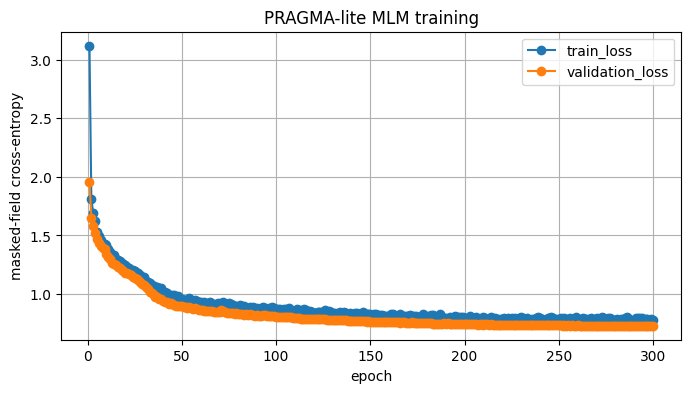

Saved artifacts:
  checkpoints_swoll/pragma_lite_mlm/best.pt
  checkpoints_swoll/pragma_lite_mlm/last.pt
  checkpoints_swoll/pragma_lite_mlm/metrics.csv
  checkpoints_swoll/pragma_lite_mlm/tokenizers/event_tokenizer_state.json
  checkpoints_swoll/pragma_lite_mlm/tokenizers/lifelong_tokenizer_state.json
  checkpoints_swoll/pragma_lite_mlm/tokenizers/profile_tokenizer_state.json


In [10]:
import matplotlib.pyplot as plt

ax = metrics.set_index('epoch')[['train_loss', 'validation_loss']].plot(
    marker='o', figsize=(8, 4), grid=True,
)
ax.set_ylabel('masked-field cross-entropy')
ax.set_title('PRAGMA-lite MLM training')
plt.show()

print('Saved artifacts:')
for path in sorted(CHECKPOINT_DIR.rglob('*')):
    if path.is_file():
        print(' ', path.relative_to(ARTIFACT_ROOT))

## Downstream transfer probe: observed loan repayment trouble

This freezes the best MLM encoder and trains only a class-balanced logistic-regression head. Each sample ends immediately **before** its loan grant date, so grant-day transactions and the `loan_granted` profile event are not inputs. The positive class is the published `B`/`D` observed problem-loan status.

This is deliberately an exploratory embedding-transfer test, not a production credit-scoring claim. The held-out test split has only eight positive examples, so inspect the bootstrap interval and do not over-interpret a single score.

In [11]:
import json
import subprocess

probe_script = PROJECT_ROOT / 'demos' / 'run_loan_probe.py'
probe_metrics_path = CHECKPOINT_DIR / 'loan_probe_metrics.json'
assert (CHECKPOINT_DIR / 'best.pt').exists(), 'Train first or set RESUME_FROM to a completed run.'
assert probe_script.exists(), (
    f'Missing {probe_script}. Copy or pull the updated project files into /content first; '
    'notebook edits alone do not sync new Python modules to the Colab runtime.'
)

subprocess.run(
    [sys.executable, str(probe_script), '--checkpoint', str(CHECKPOINT_DIR / 'best.pt'),
     '--device', DEVICE.type],
    check=True,
)

with probe_metrics_path.open(encoding='utf-8') as handle:
    loan_probe_metrics = json.load(handle)
loan_probe_metrics

{'task': 'observed_repayment_trouble_before_loan_grant',
 'positive_statuses': ['B', 'D'],
 'min_pre_grant_transactions': 20,
 'checkpoint': '/content/drive/MyDrive/FinancialBertForTransactions/checkpoints_swoll/pragma_lite_mlm/best.pt',
 'selected_logistic_c': 0.1,
 'validation_average_precision_by_c': {'0.01': 0.6218641606840365,
  '0.1': 0.6618487394957984,
  '1.0': 0.6274129096709742,
  '10.0': 0.6047309833024119},
 'validation_metrics': {'roc_auc': 0.93687707641196,
  'average_precision': 0.6618487394957984,
  'brier_score': 0.11581222368268716,
  'balanced_accuracy_at_0.5': 0.8529900332225913,
  'positive_rate': 0.07526881720430108,
  'n_examples': 93,
  'n_positive': 7},
 'test_metrics': {'roc_auc': 0.7943037974683544,
  'average_precision': 0.2788766012267991,
  'brier_score': 0.15100248758902013,
  'balanced_accuracy_at_0.5': 0.7112341772151899,
  'positive_rate': 0.09195402298850575,
  'n_examples': 87,
  'n_positive': 8},
 'test_roc_auc_bootstrap_95_interval': [0.62142783656

## Loan benchmark: tabular baseline

Before fine-tuning anything, compare the frozen embedding probe with a serious tabular logistic-regression baseline. It receives only pre-grant summaries: account age, transaction activity, money-flow, balance, and operation/category shares. Its feature schema and regularisation are fitted on train/validation only; the test split remains a final report.

The resulting report includes the prevalence baseline, tabular baseline, and the frozen probe metrics in one artifact. If the frozen probe does not beat the tabular baseline on validation, do not fine-tune loan risk yet.

In [12]:
import json
import subprocess

baseline_script = PROJECT_ROOT / 'demos' / 'run_loan_tabular_baseline.py'
baseline_metrics_path = CHECKPOINT_DIR / 'loan_tabular_baseline_metrics.json'
assert baseline_script.exists(), f'Missing {baseline_script}; sync the updated project files to /content first.'

subprocess.run(
    [sys.executable, str(baseline_script), '--output', str(baseline_metrics_path),
     '--frozen-probe-metrics', str(probe_metrics_path)],
    check=True,
)

with baseline_metrics_path.open(encoding='utf-8') as handle:
    loan_benchmark = json.load(handle)
loan_benchmark

{'task': 'observed_repayment_trouble_before_loan_grant',
 'min_pre_grant_transactions': 20,
 'feature_count': 40,
 'feature_names': ['account_age_days',
  'amount_max_abs',
  'amount_mean_abs',
  'amount_min_abs',
  'amount_std_abs',
  'amount_total_abs',
  'balance_change',
  'balance_last',
  'balance_max',
  'balance_mean',
  'balance_min',
  'balance_std',
  'category_share::HH',
  'category_share::IC',
  'category_share::IN',
  'category_share::IO',
  'category_share::ST',
  'category_share::[MISSING]',
  'category_unique_count',
  'credit_amount_abs',
  'credit_amount_share',
  'days_since_last_transaction',
  'history_active_days',
  'history_span_days',
  'history_transaction_count',
  'non_credit_amount_abs',
  'operation_share::CCW',
  'operation_share::CIC',
  'operation_share::COB',
  'operation_share::ROB',
  'operation_share::WIC',
  'operation_share::[MISSING]',
  'operation_unique_count',
  'recent_30d_amount_abs',
  'recent_30d_transaction_count',
  'trans_type_share::

## Forward-looking benchmarks: baseline versus frozen embeddings

Each task runs in two stages. First, the tabular baseline creates and saves the exact dated `task_table`: every row is an account snapshot, an input cutoff, and a future-only label. Second, the frozen Transformer probe reads that same file. This ensures both approaches are scored on precisely the same samples.

Cash-flow stress asks whether an account that is currently *above* the train-defined low-balance threshold crosses below it in the following 60 days. The future-value proxy is `log1p` of absolute transaction volume in the following 180 days. The encoder remains frozen: only a small task head is fitted on training accounts.

### Cash-flow stress: tabular baseline

This cell writes `cashflow_stress_task_table.parquet` beside its metrics JSON. The frozen probe in the next section consumes that exact cache.

In [13]:
import json
import subprocess

forward_baseline_script = PROJECT_ROOT / 'demos' / 'run_forward_task_baseline.py'
cashflow_baseline_path = CHECKPOINT_DIR / 'cashflow_tabular_baseline_metrics.json'
cashflow_task_table_path = CHECKPOINT_DIR / 'cashflow_stress_task_table.parquet'
assert forward_baseline_script.exists(), (
    f'Missing {forward_baseline_script}; sync the updated project files to /content first.'
)

subprocess.run(
    [sys.executable, str(forward_baseline_script), '--task', 'cashflow_stress',
     '--output', str(cashflow_baseline_path)],
    check=True,
)
assert cashflow_task_table_path.exists(), 'Baseline did not create the cached cash-flow task table.'

with cashflow_baseline_path.open(encoding='utf-8') as handle:
    cashflow_baseline = json.load(handle)
cashflow_baseline


{'task': 'cashflow_stress',
 'task_definition': {'cutoff_stride_days': 180,
  'min_history_transactions': 20,
  'observation_end': '2018-12-31',
  'account_disjoint_splits': True,
  'full_future_windows_only': True,
  'feature_schema_fit_on_train_only': True,
  'task_table_path': '/content/drive/MyDrive/FinancialBertForTransactions/checkpoints_swoll/pragma_lite_mlm/cashflow_stress_task_table.parquet'},
 'feature_count': 42,
 'sample_counts': {'train': 16882, 'valid': 3657, 'test': 3531},
 'low_balance_threshold': 1628.89,
 'horizon_days': 60,
 'prevalence_baseline': {'validation_metrics': {'roc_auc': 0.5,
   'average_precision': 0.17035821711785618,
   'brier_score': 0.1413640799176019,
   'balanced_accuracy_at_threshold': 0.5,
   'threshold': 0.5,
   'positive_rate': 0.17035821711785618,
   'n_examples': 3657,
   'n_positive': 623},
  'test_metrics': {'roc_auc': 0.5,
   'average_precision': 0.1719059756442934,
   'brier_score': 0.14240080858819493,
   'balanced_accuracy_at_threshold':

### Cash-flow stress: frozen Transformer probe

The Transformer receives only events at or before each cached cutoff and uses the checkpoint's saved `max_events` setting. The logistic head fits on train, selects regularisation on validation, and reports test once.

In [14]:
forward_probe_script = PROJECT_ROOT / 'demos' / 'run_forward_embedding_probe.py'
cashflow_probe_path = CHECKPOINT_DIR / 'cashflow_frozen_embedding_probe_metrics.json'
assert (CHECKPOINT_DIR / 'best.pt').exists(), 'Train first or point CHECKPOINT_DIR at a completed run.'
assert forward_probe_script.exists(), (
    f'Missing {forward_probe_script}; sync the updated project files to /content first.'
)

subprocess.run(
    [sys.executable, str(forward_probe_script), '--task', 'cashflow_stress',
     '--checkpoint', str(CHECKPOINT_DIR / 'best.pt'),
     '--task-table', str(cashflow_task_table_path),
     '--output', str(cashflow_probe_path),
     '--batch-size', str(BATCH_SIZE), '--device', DEVICE.type],
    check=True,
)

with cashflow_probe_path.open(encoding='utf-8') as handle:
    cashflow_probe = json.load(handle)

pd.DataFrame([
    {'model': 'prevalence baseline', **cashflow_baseline['prevalence_baseline']['test_metrics']},
    {'model': 'tabular logistic', **cashflow_baseline['tabular_logistic_baseline']['test_metrics']},
    {'model': 'frozen Transformer + logistic', **cashflow_probe['frozen_embedding_logistic_probe']['test_metrics']},
]).set_index('model')


,roc_auc,average_precision,brier_score,balanced_accuracy_at_threshold,threshold,positive_rate,n_examples,n_positive
model,,,,,,,,
prevalence baseline,0.500000,0.171906,0.142401,0.500000,0.5,0.171906,3531,607
tabular logistic,0.818169,0.479583,0.113597,0.544122,0.5,0.171906,3531,607
frozen Transformer + logistic,0.805345,0.461796,0.116616,0.594801,0.5,0.171906,3531,607


### Future-value proxy: tabular baseline

This is not customer lifetime value. It predicts `log1p(sum(abs(amount)))` in the following 180 days: a measurable proxy for future account activity. The output task table is cached and reused unchanged by the frozen embedding probe.

In [16]:
future_value_baseline_path = CHECKPOINT_DIR / 'future_value_tabular_baseline_metrics.json'
future_value_task_table_path = CHECKPOINT_DIR / 'future_value_task_table.parquet'

subprocess.run(
    [sys.executable, str(forward_baseline_script), '--task', 'future_value',
     '--output', str(future_value_baseline_path)],
    check=True,
)
assert future_value_task_table_path.exists(), 'Baseline did not create the cached future-value task table.'

with future_value_baseline_path.open(encoding='utf-8') as handle:
    future_value_baseline = json.load(handle)
future_value_baseline


{'task': 'future_value',
 'task_definition': {'cutoff_stride_days': 180,
  'min_history_transactions': 20,
  'observation_end': '2018-12-31',
  'account_disjoint_splits': True,
  'full_future_windows_only': True,
  'feature_schema_fit_on_train_only': True,
  'task_table_path': '/content/drive/MyDrive/FinancialBertForTransactions/checkpoints_swoll/pragma_lite_mlm/future_value_task_table.parquet'},
 'feature_count': 42,
 'sample_counts': {'train': 16790, 'valid': 3680, 'test': 3561},
 'horizon_days': 180,
 'target': 'log1p(sum(abs(amount)) in future window)',
 'mean_target_baseline': {'train_target_mean': 9.586319927277374,
  'validation_metrics': {'mae': 0.7388885796550893,
   'rmse': 0.8733113856986368,
   'r2': -1.0549133187209847e-05,
   'n_examples': 3680},
  'test_metrics': {'mae': 0.7867805474170421,
   'rmse': 0.9370277861902169,
   'r2': -0.001077084089537994,
   'n_examples': 3561}},
 'tabular_ridge_baseline': {'selected_ridge_alpha': 100.0,
  'validation_mae_by_alpha': {'0.01'

### Future-value proxy: frozen Transformer probe

A Ridge regression head is fitted on frozen account embeddings. Compare MAE and RMSE lower-is-better; R-squared higher-is-better. The mean-target baseline establishes how much better than a constant prediction each model is.

In [17]:
future_value_probe_path = CHECKPOINT_DIR / 'future_value_frozen_embedding_probe_metrics.json'

subprocess.run(
    [sys.executable, str(forward_probe_script), '--task', 'future_value',
     '--checkpoint', str(CHECKPOINT_DIR / 'best.pt'),
     '--task-table', str(future_value_task_table_path),
     '--output', str(future_value_probe_path),
     '--batch-size', str(BATCH_SIZE), '--device', DEVICE.type],
    check=True,
)

with future_value_probe_path.open(encoding='utf-8') as handle:
    future_value_probe = json.load(handle)

pd.DataFrame([
    {'model': 'mean target baseline', **future_value_baseline['mean_target_baseline']['test_metrics']},
    {'model': 'tabular Ridge', **future_value_baseline['tabular_ridge_baseline']['test_metrics']},
    {'model': 'frozen Transformer + Ridge', **future_value_probe['frozen_embedding_ridge_probe']['test_metrics']},
]).set_index('model')


,mae,rmse,r2,n_examples
model,,,,
mean target baseline,0.786781,0.937028,-0.001077,3561
tabular Ridge,0.274715,0.443365,0.775878,3561
frozen Transformer + Ridge,0.261097,0.439622,0.779646,3561


## Interpreting the comparison

For cash flow, compare average precision first because threshold crossings may be uncommon; then inspect ROC-AUC, Brier score, and the bootstrap interval. For future value, compare test MAE first, then RMSE and R-squared. A frozen embedding should beat the constant baseline and ideally approach or improve on the tabular baseline before we spend compute on task-specific fine-tuning.

Keep each checkpoint's metrics in its own `CHECKPOINT_DIR`. The saved reports make it possible to compare context-window experiments without regenerating different task labels.